In [3]:
import os
os.chdir("C:\\Users\\jenna\\Documents\\disease-risk-prediction")

os.makedirs("figures", exist_ok=True)
os.makedirs("models", exist_ok=True)

In [4]:
import pandas as pd

df = pd.read_csv("data/framingham.csv")

X = df.drop("TenYearCHD", axis=1)
y = df["TenYearCHD"] 

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000
    ))
])

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lasso_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=1000,
        C=.2,
        random_state=42
    ))
])

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)
y_prob_lasso = lasso_model.predict_proba(X_test)[:, 1]

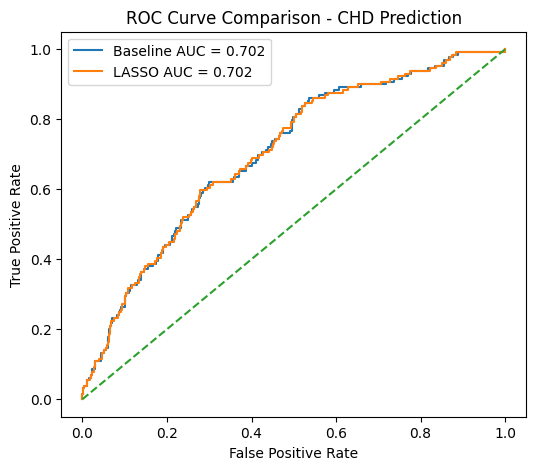

In [8]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# baseline outputs MUST exist:
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob)
auc_b = auc(fpr_b, tpr_b)

fpr_l, tpr_l, _ = roc_curve(y_test, y_prob_lasso)
auc_l = auc(fpr_l, tpr_l)

plt.figure(figsize=(6,5))

plt.plot(fpr_b, tpr_b, label=f"Baseline AUC = {auc_b:.3f}")
plt.plot(fpr_l, tpr_l, label=f"LASSO AUC = {auc_l:.3f}")
plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - CHD Prediction")
plt.legend()

plt.savefig("figures/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lasso_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=1000,
        C=.2,
        random_state=42
    ))
])

lasso_model.fit(X_train, y_train)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


<Figure size 500x500 with 0 Axes>

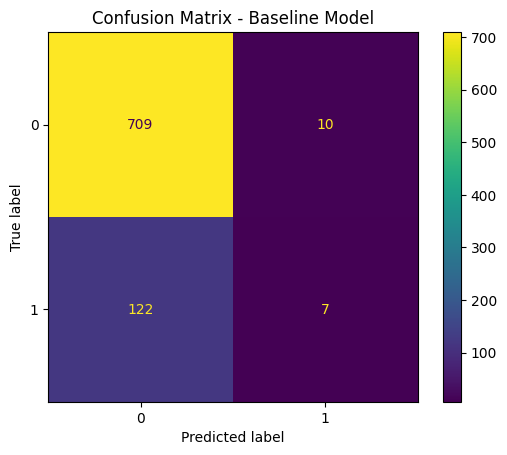

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(5,5))
disp.plot(values_format='d')

plt.title("Confusion Matrix - Baseline Model")

plt.savefig("figures/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
import pandas as pd
import numpy as np

coefficients = lasso_model.named_steps["clf"].coef_[0]

lasso_features = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": coefficients,
    "Odds Ratio": np.exp(coefficients)
})

lasso_selected = lasso_features[lasso_features["Coefficient"] != 0] \
    .sort_values(by="Odds Ratio", ascending=False)

lasso_selected.reset_index(drop=True, inplace=True)

lasso_selected.to_csv("figures/lasso_feature_importance.csv", index=False)

In [12]:
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd

results = pd.DataFrame({
    "Model": ["Baseline", "LASSO"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_lasso)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_lasso)
    ]
})

results

,Model,Accuracy,ROC-AUC
0,Baseline,0.844340,0.702192
1,LASSO,0.846698,0.702289


## ROC Interpretation

The ROC-AUC score measures the model’s ability to discriminate between patients who develop CHD and those who do not.

- 0.5 = random guessing
- 0.7 = acceptable clinical discrimination
- 0.8+ = strong model performance

This model achieves ~0.70, consistent with baseline clinical risk models.

## Clinical Insights

The strongest predictors of 10-year coronary heart disease risk include:

- Age
- Systolic blood pressure (sysBP)
- Smoking status
- Total cholesterol

These findings are consistent with established epidemiological literature, supporting model validity and interpretability.

## Model Evaluation Summary

- Dataset: Framingham Heart Study (n = 4240)
- Model: Logistic Regression with imputation + scaling
- Metric: ROC-AUC (primary)
- Result: ~0.70 (moderate discrimination)

Limitations include class imbalance and linear model assumptions.

In [14]:
from sklearn.linear_model import LogisticRegressionCV

lasso_cv = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegressionCV(
        penalty="l1",
        solver="liblinear",
        Cs=[0.05, 0.1, 0.2, 0.5, 1.0, 2.0],
        cv=5,
        scoring="roc_auc",
        max_iter=2000,
        random_state=42
    ))
])

lasso_cv.fit(X_train, y_train)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [15]:
best_c = lasso_cv.named_steps["clf"].C_[0]
print("Best C selected by cross-validation:", best_c)

Best C selected by cross-validation: 0.2


In [16]:
from sklearn.metrics import accuracy_score, roc_auc_score

y_pred_cv = lasso_cv.predict(X_test)
y_prob_cv = lasso_cv.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_cv))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_cv))

Accuracy: 0.8466981132075472
ROC-AUC: 0.702288924108635


In [17]:
import numpy as np

coef = lasso_cv.named_steps["clf"].coef_[0]

print("Non-zero coefficients:", np.count_nonzero(coef))
print("Total coefficients:", len(coef))

Non-zero coefficients: 12
Total coefficients: 15


In [18]:
import pandas as pd
import numpy as np

feature_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": coef,
    "Odds Ratio": np.exp(coef)
})

feature_table = feature_table[feature_table["Coefficient"] != 0]
feature_table = feature_table.sort_values(
    by="Odds Ratio",
    ascending=False
).reset_index(drop=True)

feature_table

,Feature,Coefficient,Odds Ratio
0,age,0.557659,1.746579
1,sysBP,0.303686,1.354843
2,cigsPerDay,0.250845,1.285110
3,male,0.208286,1.231565
4,glucose,0.157524,1.170609
5,totChol,0.091479,1.095794
6,prevalentStroke,0.088133,1.092134
7,prevalentHyp,0.065112,1.067279
8,BPMeds,0.061325,1.063244
9,diabetes,0.018323,1.018491


<Figure size 600x600 with 0 Axes>

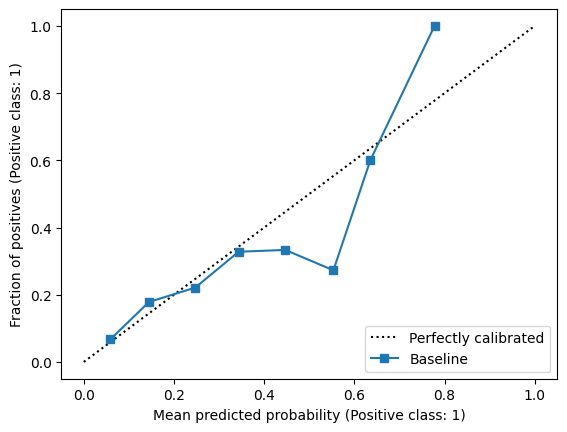

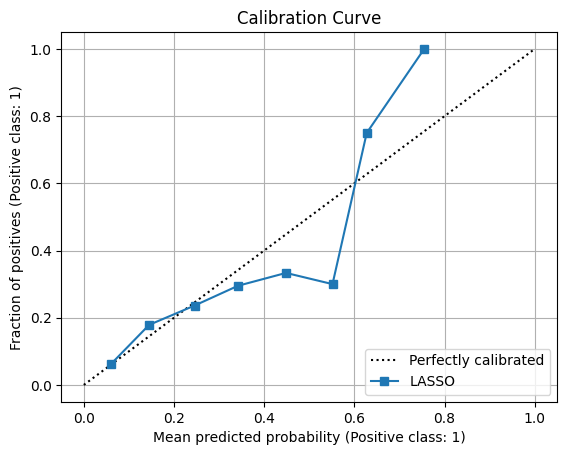

In [19]:
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

CalibrationDisplay.from_predictions(
    y_test,
    y_prob,
    n_bins=10,
    name="Baseline"
)

CalibrationDisplay.from_predictions(
    y_test,
    y_prob_lasso,
    n_bins=10,
    name="LASSO"
)

plt.title("Calibration Curve")
plt.grid(True)

plt.savefig(
    "figures/calibration_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
from sklearn.metrics import brier_score_loss

baseline_brier = brier_score_loss(y_test, y_prob)
lasso_brier = brier_score_loss(y_test, y_prob_lasso)

print("Baseline Brier Score:", baseline_brier)
print("LASSO Brier Score:", lasso_brier)

Baseline Brier Score: 0.12135951240082134
LASSO Brier Score: 0.12105164080041127


In [21]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    baseline_model,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("Fold ROC-AUC Scores:")
print(cv_scores)

print("\nMean ROC-AUC:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Fold ROC-AUC Scores:
[0.71102431 0.71898955 0.71563649 0.73841791 0.7390109 ]

Mean ROC-AUC: 0.7246158324213934
Standard Deviation: 0.011787524602219983


In [22]:
import numpy as np
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(42)

n_bootstraps = 2000
boot_scores = []

y_test_array = np.array(y_test)
y_prob_array = np.array(y_prob_lasso)

for _ in range(n_bootstraps):

    indices = rng.integers(
        0,
        len(y_test_array),
        len(y_test_array)
    )

    # ROC-AUC requires both classes
    if len(np.unique(y_test_array[indices])) < 2:
        continue

    score = roc_auc_score(
        y_test_array[indices],
        y_prob_array[indices]
    )

    boot_scores.append(score)

boot_scores = np.array(boot_scores)

lower = np.percentile(boot_scores, 2.5)
upper = np.percentile(boot_scores, 97.5)
mean_auc = np.mean(boot_scores)

print(f"Bootstrap Mean ROC-AUC: {mean_auc:.3f}")
print(f"95% Confidence Interval: ({lower:.3f}, {upper:.3f})")

Bootstrap Mean ROC-AUC: 0.702
95% Confidence Interval: (0.654, 0.746)


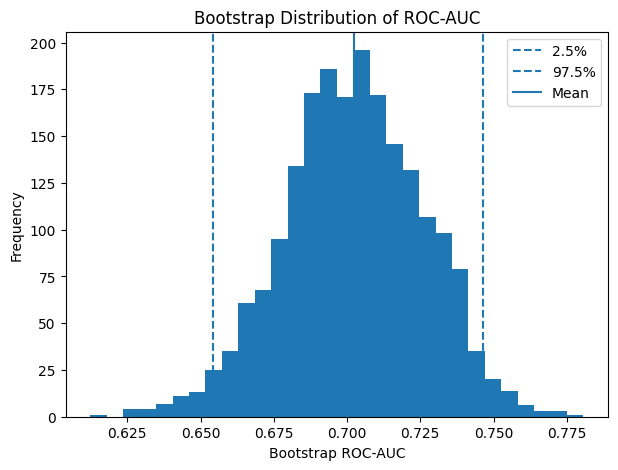

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.hist(boot_scores, bins=30)

plt.axvline(lower, linestyle="--", label="2.5%")
plt.axvline(upper, linestyle="--", label="97.5%")
plt.axvline(mean_auc, label="Mean")

plt.xlabel("Bootstrap ROC-AUC")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of ROC-AUC")

plt.legend()

plt.savefig(
    "figures/bootstrap_auc_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
results.to_csv(
    "figures/model_comparison.csv",
    index=False
)

C:\Users\jenna\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


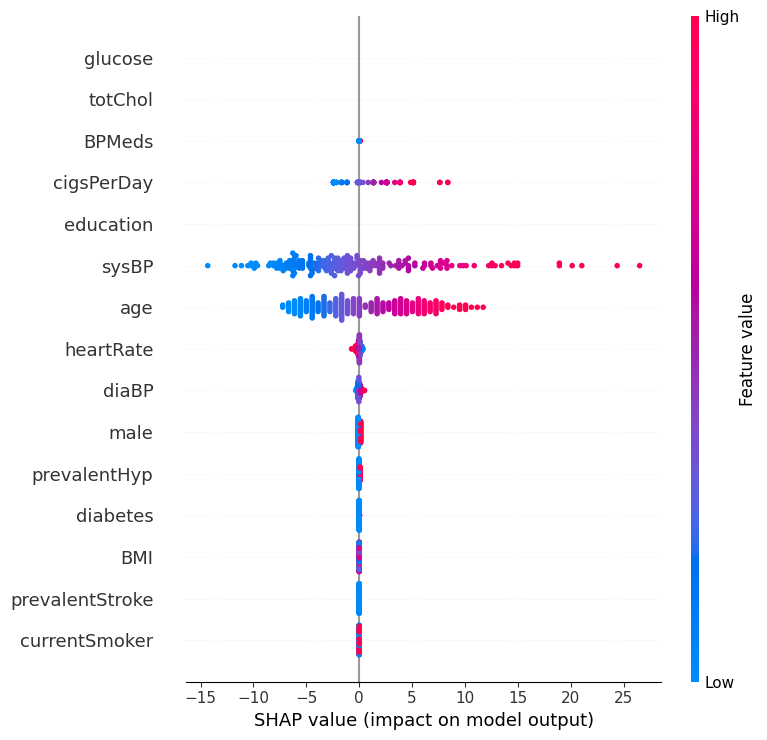

In [28]:
import shap

# use a small sample for speed
X_sample = X_test.sample(200, random_state=42)

explainer = shap.LinearExplainer(lasso_model.named_steps["clf"], X_sample)
shap_values = explainer(X_sample)

shap.summary_plot(shap_values, X_sample)

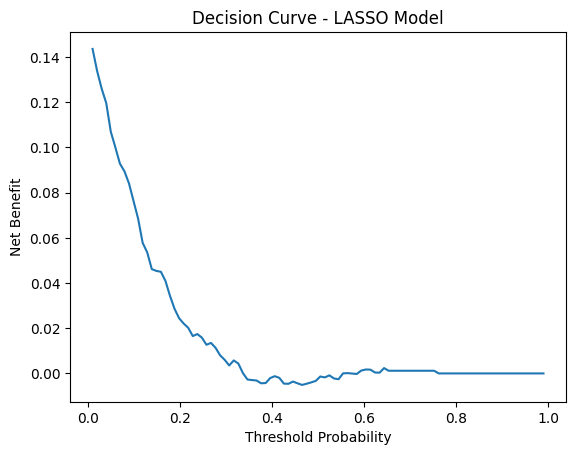

In [29]:
import numpy as np

thresholds = np.linspace(0.01, 0.99, 100)

net_benefit = []

for t in thresholds:
    preds = (y_prob_lasso >= t).astype(int)
    tp = ((preds == 1) & (y_test == 1)).sum()
    fp = ((preds == 1) & (y_test == 0)).sum()
    n = len(y_test)

    nb = (tp/n) - (fp/n) * (t/(1-t))
    net_benefit.append(nb)

import matplotlib.pyplot as plt

plt.plot(thresholds, net_benefit)
plt.xlabel("Threshold Probability")
plt.ylabel("Net Benefit")
plt.title("Decision Curve - LASSO Model")
plt.show()